In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import precision_score,recall_score,roc_auc_score,accuracy_score,classification_report,confusion_matrix

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/drive/MyDrive/breast1.csv breast1.csv

In [ ]:
df = pd.read_csv('breast1.csv', encoding='latin-1') # Try reading the file with 'latin-1' encoding. If this doesn't work, try other encodings like 'cp1252'.
df.shape

(569, 32)

In [ ]:
df.head()

,ï»¿id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.rename(columns={'ï»¿id': 'id'}, inplace=True)

In [ ]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [ ]:
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})

In [ ]:
df.corr(numeric_only=True)['diagnosis'].sort_values(ascending=False)

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
perimeter_mean,0.742636
area_worst,0.733825
radius_mean,0.730029
area_mean,0.708984
concavity_mean,0.696360


EDA

<Axes: >

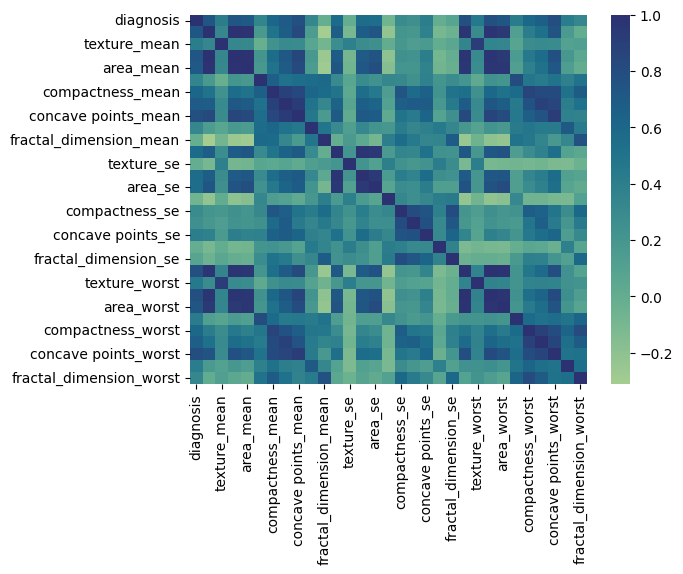

In [ ]:
sns.heatmap(df.drop('id',axis=1).corr(),cmap='crest')

<Axes: ylabel='count'>

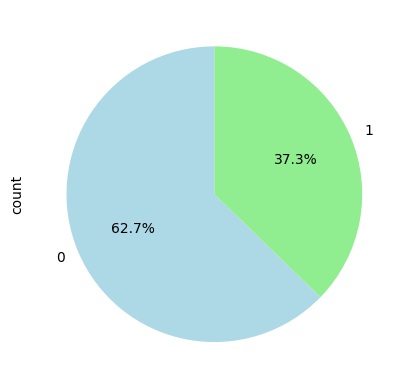

In [ ]:
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors = ['#add8e6', '#90ee90'])

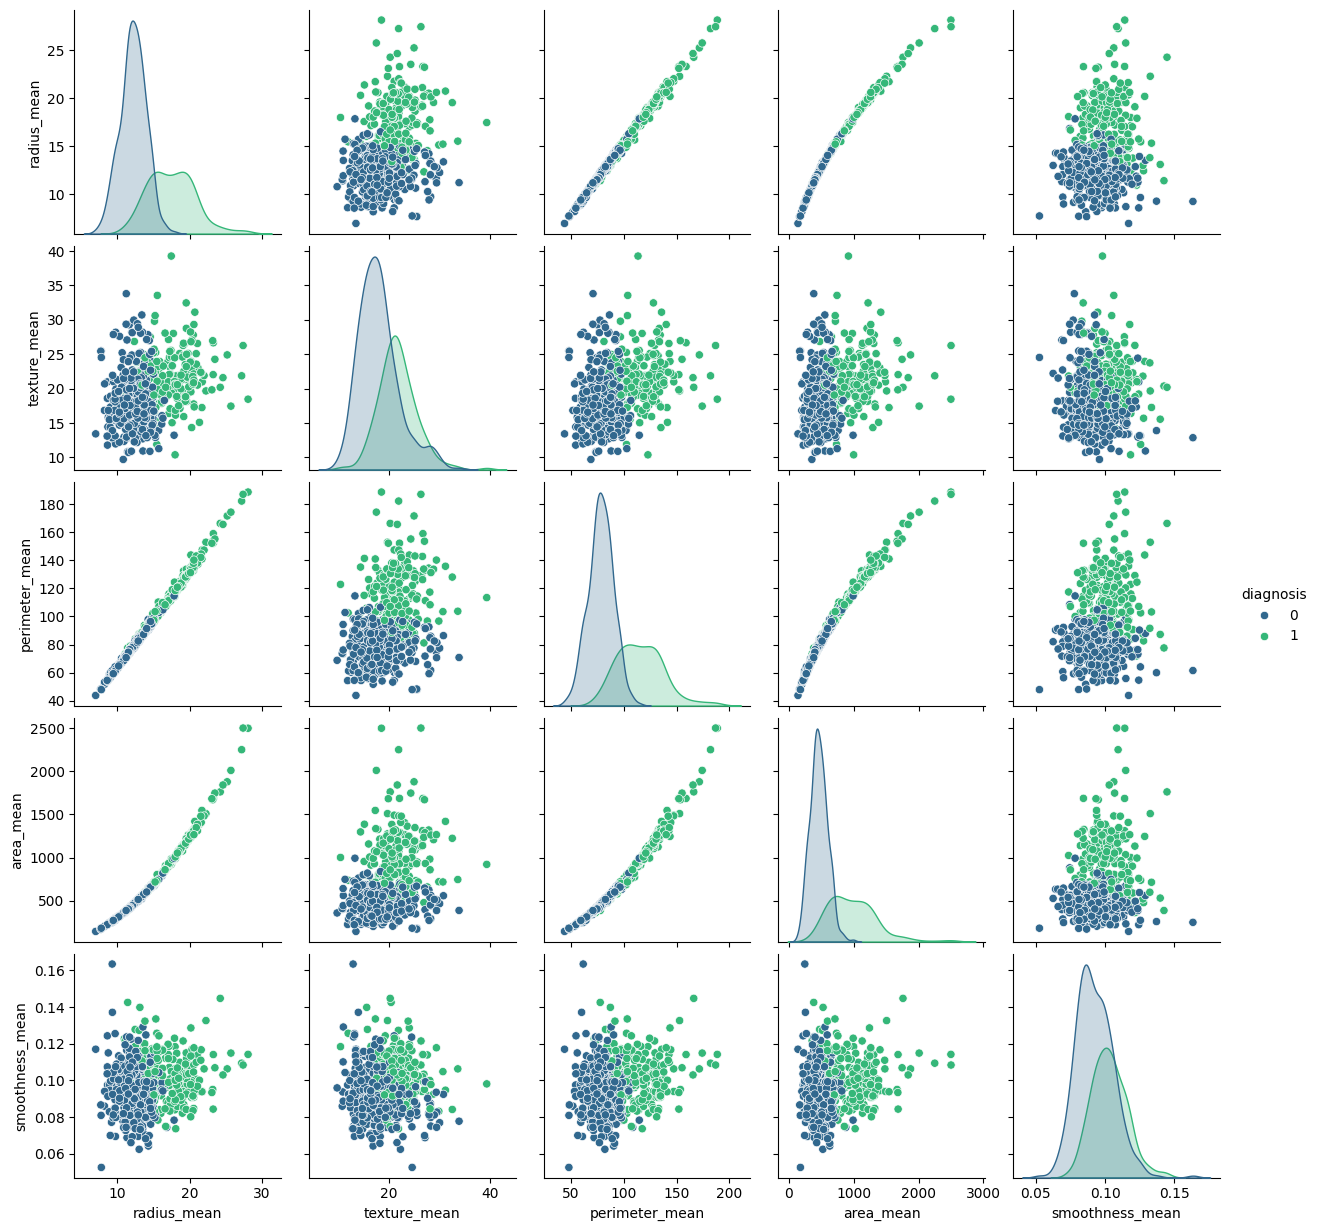

In [ ]:
sns.pairplot(df[['diagnosis','radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean']],hue='diagnosis',palette='viridis')

Text(0.5, 1.0, 'Distribution of Concave worst points.')

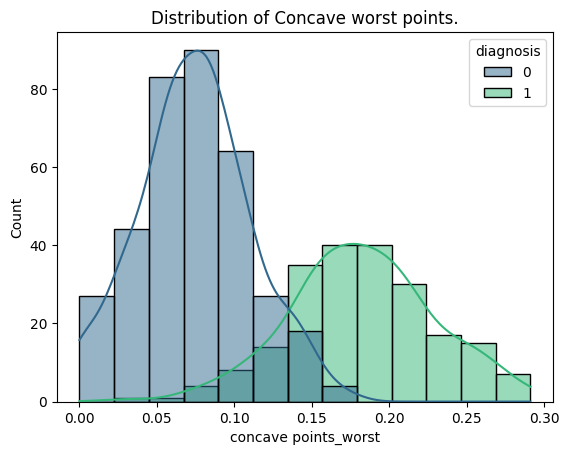

In [ ]:
plt.figure(dpi=100)
sns.histplot(x=df['concave points_worst'],data=df,kde=True,hue='diagnosis',palette='viridis')
plt.title('Distribution of Concave worst points.')

Text(0.5, 1.0, 'Perimeter worst vs Concave points worst')

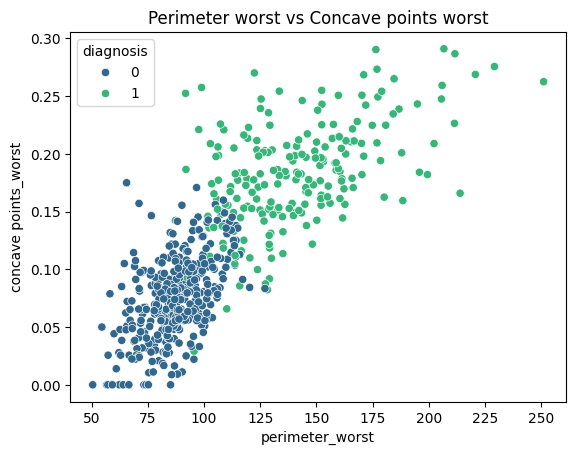

In [ ]:
sns.scatterplot(x=df['perimeter_worst'],y=df['concave points_worst'],hue='diagnosis',data=df,palette='viridis')
plt.title('Perimeter worst vs Concave points worst')

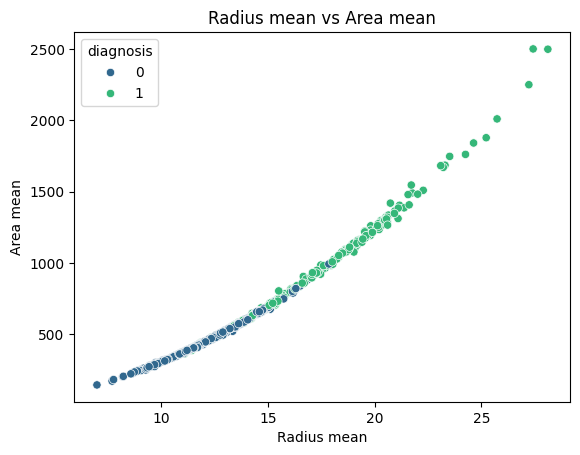

In [ ]:


sns.scatterplot(x=df['radius_mean'],y=df['area_mean'],hue='diagnosis',data=df,palette='viridis')
plt.title('Radius mean vs Area mean')
plt.xlabel('Radius mean')
plt.ylabel('Area mean')
plt.show()

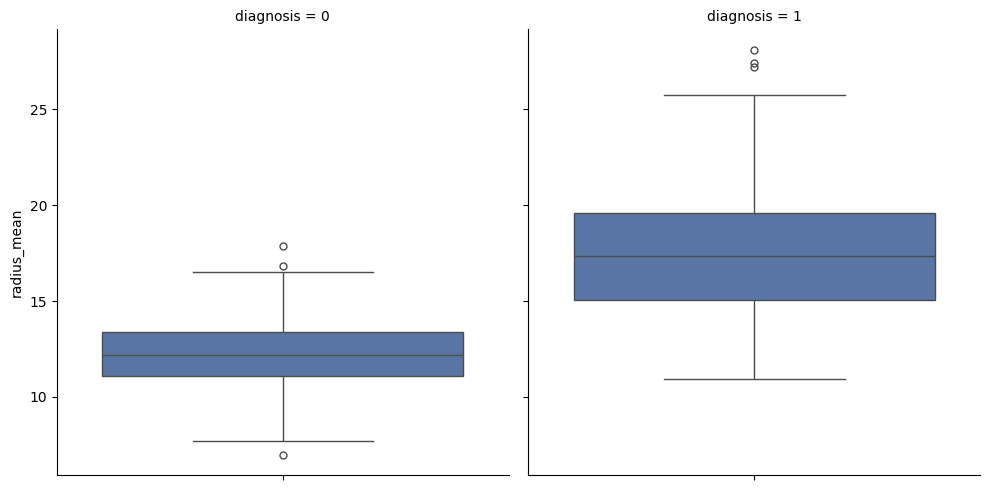

In [ ]:
sns.catplot(y='radius_mean',data=df,kind='box',palette='deep',col='diagnosis')

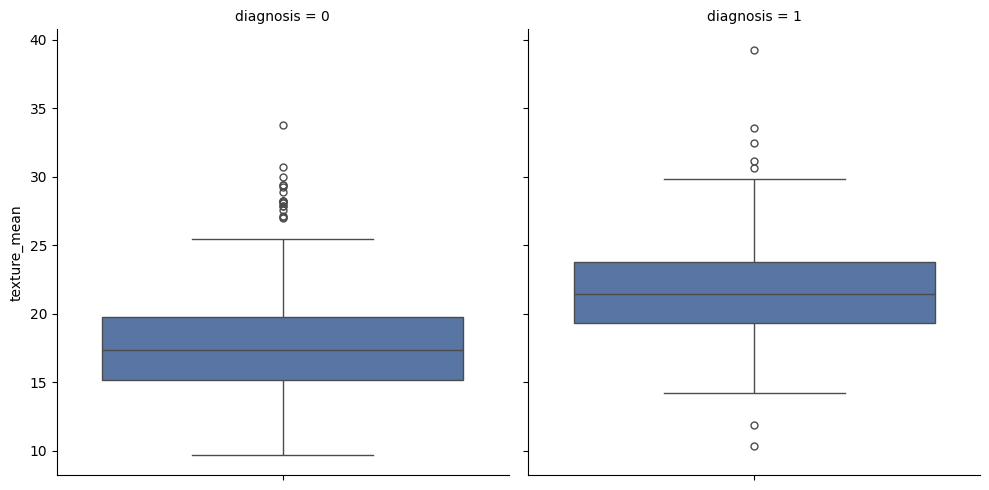

In [ ]:
sns.catplot(y='texture_mean',data=df,kind='box',palette='deep',col='diagnosis')

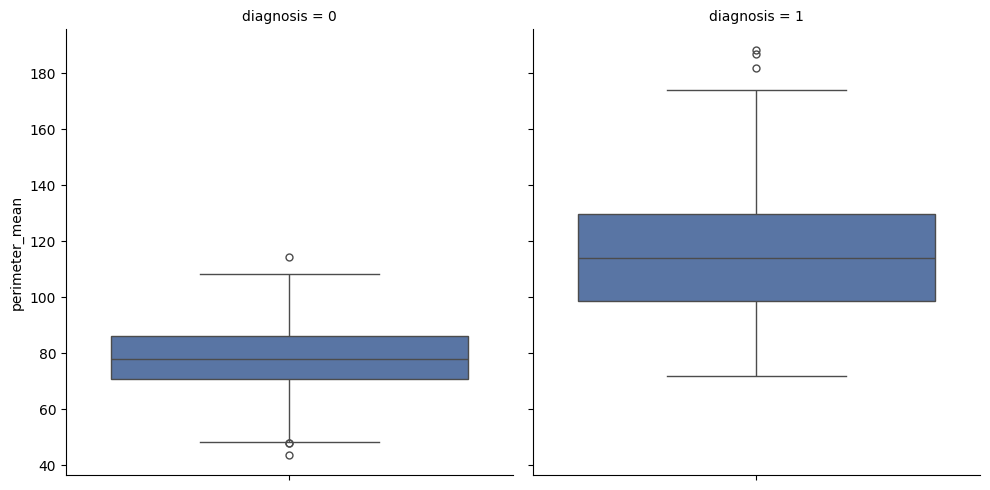

In [ ]:
sns.catplot(y='perimeter_mean',data=df,kind='box',palette='deep',col='diagnosis')

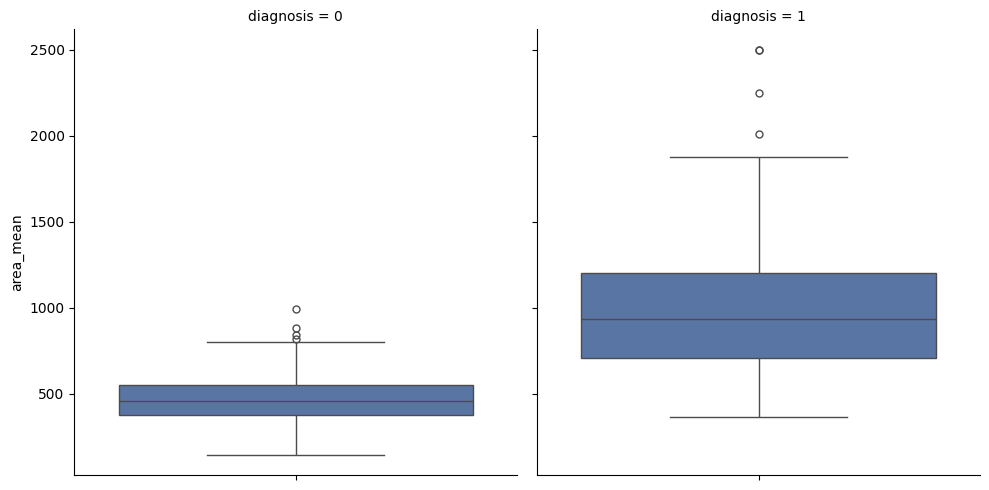

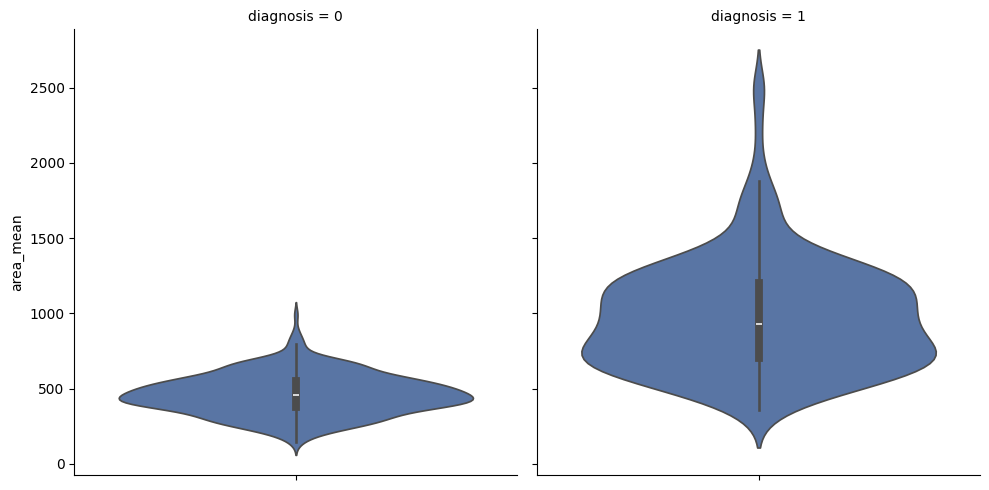

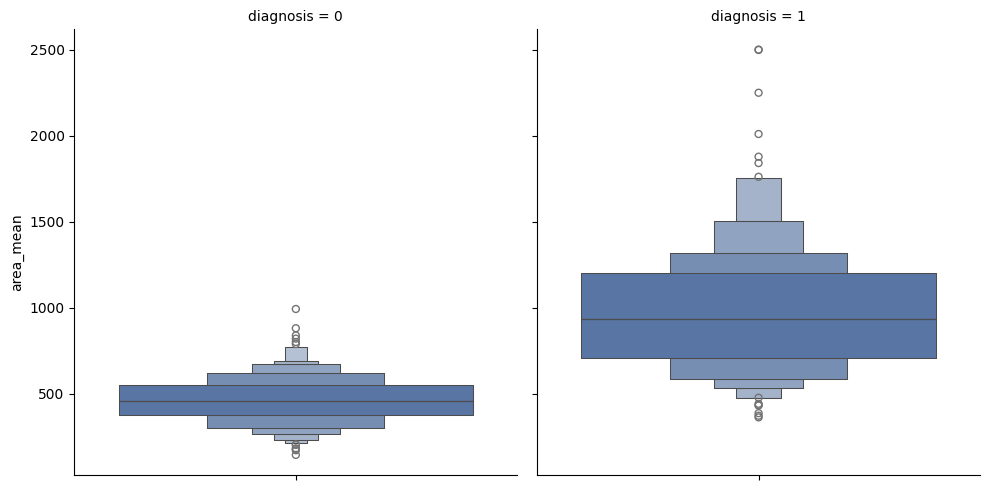

In [ ]:


sns.catplot(y='area_mean',data=df,kind='box',palette='deep',col='diagnosis')
sns.catplot(y='area_mean',data=df,kind='violin',palette='deep',col='diagnosis')
sns.catplot(y='area_mean',data=df,kind='boxen',palette='deep',col='diagnosis')

<Axes: xlabel='perimeter_worst', ylabel='Count'>

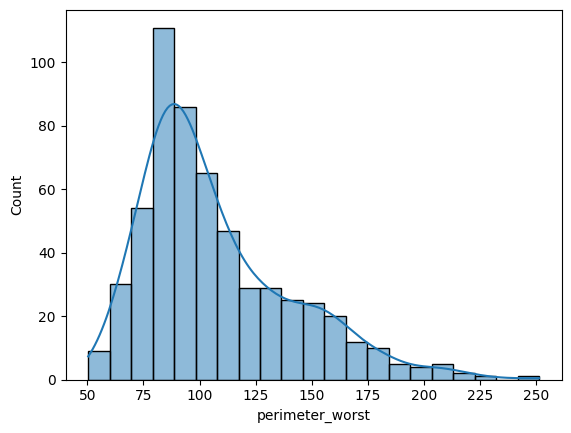

In [ ]:
sns.histplot(x=df['perimeter_worst'],data=df,kde=True)

In [ ]:
df.isnull().sum().sum()

0

In [ ]:
def detect_outliers(column,df):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

    return df

In [ ]:
df=detect_outliers('radius_mean',df)
df=detect_outliers('texture_mean',df)
df=detect_outliers('perimeter_mean',df)
df=detect_outliers('area_mean',df)

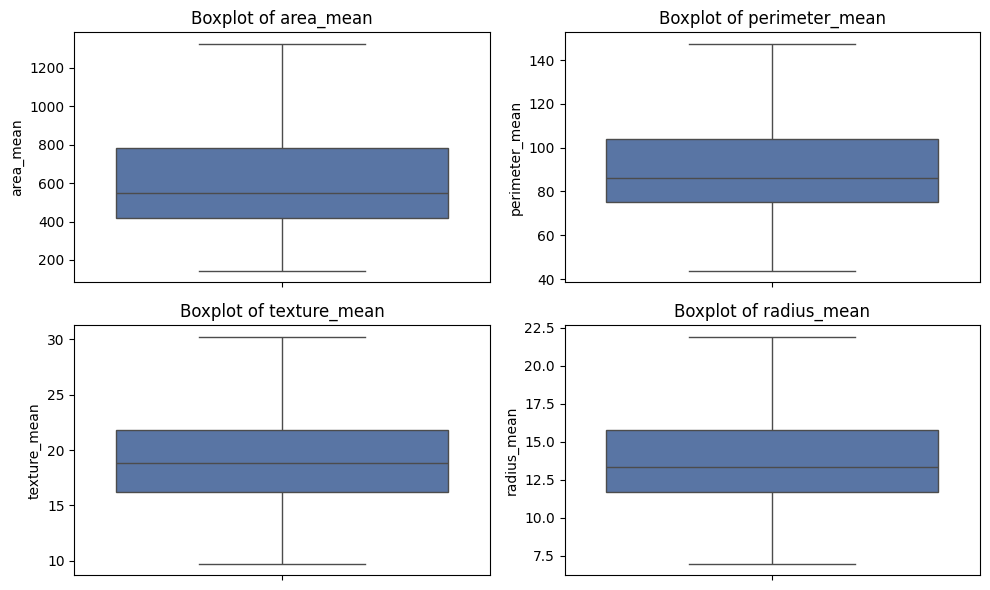

In [ ]:
features = ['area_mean', 'perimeter_mean', 'texture_mean', 'radius_mean']

fig, axes = plt.subplots(2, 2, figsize=(10,6),dpi=100)  # 2 rows, 2 columns

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(y=feature, data=df, palette='deep', ax=axes[i])
    axes[i].set_title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df['diameter_mean'] = 2 * df['radius_mean']
df['diameter_se'] = 2 * df['radius_se']
df['diameter_worst'] = 2 * df['radius_worst']

In [ ]:
df['circumference_mean'] = 2 * np.pi * df['radius_mean']
df['circumference_se'] = 2 * np.pi * df['radius_se']
df['circumference_worst'] = 2 * np.pi * df['radius_worst']

In [ ]:
df.corr()['diagnosis'].sort_values(ascending=False)

,diagnosis
diagnosis,1.000000
concave points_worst,0.793566
perimeter_worst,0.782914
concave points_mean,0.776614
radius_worst,0.776454
diameter_worst,0.776454
circumference_worst,0.776454
perimeter_mean,0.759006
area_mean,0.752786
diameter_mean,0.745217


In [ ]:
df.drop('id',axis=1,inplace=True)

In [ ]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diameter_mean,diameter_se,diameter_worst,circumference_mean,circumference_se,circumference_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,35.98,2.1900,50.760,113.034504,6.880088,159.467243
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,41.14,1.0870,49.980,129.245122,3.414911,157.016801
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,39.38,1.4912,47.140,123.715919,4.684743,148.094678
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,22.84,0.9912,29.820,71.753976,3.113947,93.682293
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,40.58,1.5144,45.080,127.485830,4.757628,141.622997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1326.3,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,43.12,2.3520,50.900,135.465475,7.389026,159.907066
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,40.26,1.5310,47.380,126.480520,4.809778,148.848660
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,33.20,0.9128,37.960,104.300876,2.867646,119.254857
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,41.20,1.4520,51.480,129.433617,4.561593,161.729190


In [ ]:
X=df.drop('diagnosis',axis=1)
y=df['diagnosis']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, shuffle=True)

print(X_val.shape)
print(X_test.shape)
print(X_train.shape)

(85, 36)
(86, 36)
(398, 36)


In [ ]:
scaler=StandardScaler()
scaler.fit(X_train)
train_scaled = scaler.transform(X_train)
val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(X_test)

In [ ]:
y_train.value_counts()

,count
diagnosis,
0,249
1,149


In [ ]:
def grid_search_run(param_grid,model):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(train_scaled, y_train)

    return grid_search

In [ ]:
results = []

In [ ]:
param_grid = {
    'C':np.logspace(-20,0,20),
    'solver': ['liblinear', 'lbfgs', 'saga', 'newton-cg'],
    'penalty':['l2','l1']
}

log_model=grid_search_run(param_grid,LogisticRegression())
y_pred=log_model.predict(val_scaled)
y_pred_train=log_model.predict(train_scaled)
print('Logistic Regression')
print('Training Accuracy: ',accuracy_score(y_train,y_pred_train))
print('Testing Accuracy: ',accuracy_score(y_val,y_pred))
print('Precision: ',precision_score(y_val,y_pred))
print('Recall: ',recall_score(y_val,y_pred))
print('ROC_AUC: ',roc_auc_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred)
})

Logistic Regression
Training Accuracy:  0.9849246231155779
Testing Accuracy:  0.9882352941176471
Precision:  1.0
Recall:  0.972972972972973
ROC_AUC:  0.9864864864864865
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       1.00      0.97      0.99        37

    accuracy                           0.99        85
   macro avg       0.99      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



In [ ]:
log_model

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-20, 1.12883789e-19, 1.27427499e-18, 1.43844989e-17,
       1.62377674e-16, 1.83298071e-15, 2.06913808e-14, 2.33572147e-13,
       2.63665090e-12, 2.97635144e-11, 3.35981829e-10, 3.79269019e-09,
       4.28133240e-08, 4.83293024e-07, 5.45559478e-06, 6.15848211e-05,
       6.95192796e-04, 7.84759970e-03, 8.85866790e-02, 1.00000000e+00]),
                         'penalty': ['l2', 'l1'],
                         'solver': ['liblinear', 'lbfgs', 'saga', 'newton-cg']},
             scoring='accuracy')

Best K value:  16


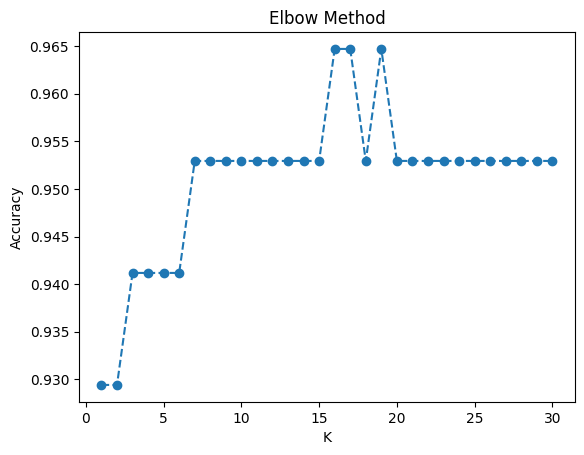

In [ ]:
#Using elbow method to find the best k value
accuracies = []
for i in range(1,31):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(train_scaled,y_train)
    pred_i=knn.predict(val_scaled)
    accuracies.append(accuracy_score(y_val,pred_i))

plt.figure(dpi=100)
plt.plot(range(1,31),accuracies,marker='o',linestyle='dashed')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Accuracy')
print('Best K value: ',accuracies.index(max(accuracies))+1)

In [ ]:
knn_model=KNeighborsClassifier(n_neighbors=accuracies.index(max(accuracies))+1)
knn_model.fit(train_scaled,y_train)
y_pred=knn_model.predict(val_scaled)

print('KNN')
print('Test Accuracy: ',accuracy_score(y_val,y_pred))
print('Precision: ',precision_score(y_val,y_pred))
print('Recall: ',recall_score(y_val,y_pred))
print('ROC_AUC: ',roc_auc_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred)
})

KNN
Test Accuracy:  0.9647058823529412
Precision:  0.9722222222222222
Recall:  0.9459459459459459
ROC_AUC:  0.9625563063063064
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        48
           1       0.97      0.95      0.96        37

    accuracy                           0.96        85
   macro avg       0.97      0.96      0.96        85
weighted avg       0.96      0.96      0.96        85



In [ ]:


param_grid = {
    'max_depth': [None, 10, 20, 30,40],
    'min_samples_split': [2,5,8,10,13,15,19],
    'min_samples_leaf': [1,2,3,4,5,6,7,8],
    'criterion': ['gini', 'entropy','log_loss']  # Criterion to measure the quality of a split
}
DT_model=grid_search_run(param_grid,DecisionTreeClassifier())
y_pred=DT_model.predict(val_scaled)

print('Decision Tree')
print('Test Accuracy: ',accuracy_score(y_val,y_pred))
print('Precision: ',precision_score(y_val,y_pred))
print('Recall: ',recall_score(y_val,y_pred))
print('ROC_AUC: ',roc_auc_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred)
})



Decision Tree
Test Accuracy:  0.9411764705882353
Precision:  0.9705882352941176
Recall:  0.8918918918918919
ROC_AUC:  0.9355292792792793
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        48
           1       0.97      0.89      0.93        37

    accuracy                           0.94        85
   macro avg       0.95      0.94      0.94        85
weighted avg       0.94      0.94      0.94        85



In [ ]:
param_grid= {
    'n_estimators': [50,100,150,200,250],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

Ada_model=grid_search_run(param_grid,AdaBoostClassifier())
y_pred=Ada_model.predict(val_scaled)

print('Ada Boost')
print('Test Accuracy: ',accuracy_score(y_val,y_pred))
print('Precision: ',precision_score(y_val,y_pred))
print('Recall: ',recall_score(y_val,y_pred))
print('ROC_AUC: ',roc_auc_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

results.append({
    'Model': 'Ada Boost',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred)
})

Ada Boost
Test Accuracy:  0.9647058823529412
Precision:  0.9473684210526315
Recall:  0.972972972972973
ROC_AUC:  0.9656531531531533
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        48
           1       0.95      0.97      0.96        37

    accuracy                           0.96        85
   macro avg       0.96      0.97      0.96        85
weighted avg       0.97      0.96      0.96        85



In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'max_depth': [3, 5, 7]
}

gradient_model=grid_search_run(param_grid,GradientBoostingClassifier())
y_pred=gradient_model.predict(val_scaled)
print('Gradient Boosting')
print('Test Accuracy: ',accuracy_score(y_val,y_pred))
print('Precision: ',precision_score(y_val,y_pred))
print('Recall: ',recall_score(y_val,y_pred))
print('ROC_AUC: ',roc_auc_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_val, y_pred),
    'Precision': precision_score(y_val, y_pred),
    'Recall': recall_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred)
})

Gradient Boosting
Test Accuracy:  0.9176470588235294
Precision:  0.8571428571428571
Recall:  0.972972972972973
ROC_AUC:  0.9239864864864865
              precision    recall  f1-score   support

           0       0.98      0.88      0.92        48
           1       0.86      0.97      0.91        37

    accuracy                           0.92        85
   macro avg       0.92      0.92      0.92        85
weighted avg       0.92      0.92      0.92        85



In [ ]:
summary=pd.DataFrame(results)
summary=summary.reindex()
print(summary)

                 Model  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression  0.988235   1.000000  0.972973  0.986486
1                  KNN  0.964706   0.972222  0.945946  0.962556
2        Decision Tree  0.941176   0.970588  0.891892  0.935529
3            Ada Boost  0.964706   0.947368  0.972973  0.965653
4    Gradient Boosting  0.917647   0.857143  0.972973  0.923986


In [ ]:
from sklearn.metrics import classification_report

name = ['log', 'DT', 'knn', 'Ada', 'gradient']
models = [log_model, DT_model, knn_model, Ada_model, gradient_model]
results_list = []

for i, model in enumerate(models):  # Enumerate to get index i
    y_pred = model.predict(test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)

    results_list.append({
        'Model': name[i],  # Use index i to access name element
        'Precision_0': report['0']['precision'],
        'Precision_1': report['1']['precision'],
        'Recall_0': report['0']['recall'],
        'Recall_1': report['1']['recall'],
        'F1_0': report['0']['f1-score'],
        'F1_1': report['1']['f1-score']
    })

results_df = pd.DataFrame(results_list)
results_df

,Model,Precision_0,Precision_1,Recall_0,Recall_1,F1_0,F1_1
0,log,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,DT,0.967213,0.960000,0.983333,0.923077,0.975207,0.941176
2,knn,0.937500,1.000000,1.000000,0.846154,0.967742,0.916667
3,Ada,0.983333,0.961538,0.983333,0.961538,0.983333,0.961538
4,gradient,0.982456,0.862069,0.933333,0.961538,0.957265,0.909091


In [ ]:
import pickle

In [ ]:
output_file = f'log_model.bin'
output_file

'log_model.bin'

In [ ]:
f_out = open(output_file, 'wb')
pickle.dump(log_model, f_out)
f_out.close()

In [ ]:
with open(output_file, 'wb') as f_out:
    pickle.dump(log_model, f_out)

In [ ]:
pd.test_scaled

AttributeError: module 'pandas' has no attribute 'test_scaled'

In [ ]:
X_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diameter_mean,diameter_se,diameter_worst,circumference_mean,circumference_se,circumference_worst
140,9.738,11.97,61.24,288.5,0.09250,0.04102,0.000000,0.000000,0.1903,0.06422,0.1988,0.4960,1.218,12.26,0.006040,0.005656,0.000000,0.000000,0.02277,0.003220,10.620,14.10,66.53,342.9,0.12340,0.07204,0.000000,0.00000,0.3105,0.08151,19.476,0.3976,21.240,61.185659,1.249097,66.727428
464,13.170,18.22,84.28,537.3,0.07466,0.05994,0.048590,0.028700,0.1454,0.05549,0.2023,0.6850,1.236,16.89,0.005969,0.014930,0.015640,0.008463,0.01093,0.001672,14.900,23.89,95.10,687.6,0.12820,0.19650,0.187600,0.10450,0.2235,0.06925,26.340,0.4046,29.800,82.749550,1.271088,93.619461
320,10.250,16.18,66.52,324.2,0.10610,0.11110,0.067260,0.039650,0.1743,0.07279,0.3677,1.4710,1.597,22.68,0.010490,0.042650,0.040040,0.015440,0.02719,0.007596,11.280,20.61,71.53,390.4,0.14020,0.23600,0.189800,0.09744,0.2608,0.09702,20.500,0.7354,22.560,64.402649,2.310327,70.874330
199,14.450,20.22,94.49,642.7,0.09872,0.12060,0.118000,0.059800,0.1950,0.06466,0.2092,0.6509,1.446,19.42,0.004044,0.015970,0.020000,0.007303,0.01522,0.001976,18.330,30.12,117.90,1044.0,0.15520,0.40560,0.496700,0.18380,0.4753,0.10130,28.900,0.4184,36.660,90.792028,1.314442,115.170787
568,7.760,24.54,47.92,181.0,0.05263,0.04362,0.000000,0.000000,0.1587,0.05884,0.3857,1.4280,2.548,19.15,0.007189,0.004660,0.000000,0.000000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.000000,0.00000,0.2871,0.07039,15.520,0.7714,18.912,48.757518,2.423425,59.413800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,13.530,10.94,87.91,559.2,0.12910,0.10470,0.068770,0.065560,0.2403,0.06641,0.4101,1.0140,2.652,32.65,0.013400,0.028390,0.011620,0.008239,0.02572,0.006164,14.080,12.49,91.36,605.5,0.14510,0.13790,0.085390,0.07407,0.2710,0.07191,27.060,0.8202,28.160,85.011497,2.576734,88.467249
425,10.030,21.28,63.19,307.3,0.08117,0.03912,0.002470,0.005159,0.1630,0.06439,0.1851,1.3410,1.184,11.60,0.005724,0.005697,0.002074,0.003527,0.01445,0.002411,11.110,28.94,69.92,376.3,0.11260,0.07094,0.012350,0.02579,0.2349,0.08061,20.060,0.3702,22.220,63.020349,1.163018,69.806189
117,14.870,16.67,98.64,682.5,0.11620,0.16490,0.169000,0.089230,0.2157,0.06768,0.4266,0.9489,2.989,41.18,0.006985,0.025630,0.030110,0.012710,0.01602,0.003884,18.810,27.37,127.10,1095.0,0.18780,0.44800,0.470400,0.20270,0.3585,0.10650,29.740,0.8532,37.620,93.430966,2.680407,118.186716
333,11.250,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,0.1773,0.06081,0.2144,0.9961,1.529,15.07,0.005617,0.007124,0.000974,0.002941,0.01700,0.002030,12.760,22.06,82.08,492.7,0.11660,0.09794,0.005518,0.01667,0.2815,0.07418,22.500,0.4288,25.520,70.685835,1.347115,80.173445


In [ ]:
row_dict = X_test.iloc[43].to_dict()
print(row_dict)

{'radius_mean': 12.96, 'texture_mean': 18.29, 'perimeter_mean': 84.18, 'area_mean': 525.2, 'smoothness_mean': 0.07351, 'compactness_mean': 0.07899, 'concavity_mean': 0.04057, 'concave points_mean': 0.01883, 'symmetry_mean': 0.1874, 'fractal_dimension_mean': 0.05899, 'radius_se': 0.2357, 'texture_se': 1.299, 'perimeter_se': 2.397, 'area_se': 20.21, 'smoothness_se': 0.003629, 'compactness_se': 0.03713, 'concavity_se': 0.03452, 'concave points_se': 0.01065, 'symmetry_se': 0.02632, 'fractal_dimension_se': 0.003705, 'radius_worst': 14.13, 'texture_worst': 24.61, 'perimeter_worst': 96.31, 'area_worst': 621.9, 'smoothness_worst': 0.09329, 'compactness_worst': 0.2318, 'concavity_worst': 0.1604, 'concave points_worst': 0.06608, 'symmetry_worst': 0.3207, 'fractal_dimension_worst': 0.07247, 'diameter_mean': 25.92, 'diameter_se': 0.4714, 'diameter_worst': 28.26, 'circumference_mean': 81.43008158104745, 'circumference_se': 1.4809467769022284, 'circumference_worst': 88.78140839044755}


In [ ]:
# -*- coding: utf-8 -*-
"""capstone1_pipeline.ipynb
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, roc_auc_score,
                             accuracy_score, classification_report)

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# 1. Load and prepare the data
# ------------------------------------------------------------------------------
df = pd.read_csv('breast1.csv', encoding='latin-1')  # Adjust if needed

# Map the target variable
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Rename columns
df.rename(columns={'ï»¿id': 'id'}, inplace=True)
df.drop('id', axis=1, inplace=True)

# Features/labels split
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Train/validation/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Validation set shape: ", X_val.shape)
print("Test set shape:       ", X_test.shape)
print("Train set shape:      ", X_train.shape)

# ------------------------------------------------------------------------------
# 2. Create a pipeline with preprocessing + model
# ------------------------------------------------------------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression())
])

# Define the parameter grid for GridSearchCV
# Note that we prefix the hyperparameters with the pipeline step name:
# 'logistic__' corresponds to the 'logistic' step in the pipeline
param_grid = {
    'logistic__C': np.logspace(-4, 4, 10),
    'logistic__solver': ['liblinear', 'lbfgs', 'newton-cg', 'saga'],
    'logistic__penalty': ['l1', 'l2']  # 'l1' works only for 'liblinear' or 'saga'
}

# ------------------------------------------------------------------------------
# 3. Run Grid Search on the pipeline
# ------------------------------------------------------------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

# ------------------------------------------------------------------------------
# 4. Evaluate on the validation set
# ------------------------------------------------------------------------------
y_pred_val = grid_search.predict(X_val)
y_pred_train = grid_search.predict(X_train)

print("\n=== Logistic Regression (via Pipeline) ===")
print("Training Accuracy: ", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy: ", accuracy_score(y_val, y_pred_val))
print("Precision: ", precision_score(y_val, y_pred_val))
print("Recall: ", recall_score(y_val, y_pred_val))
print("ROC_AUC: ", roc_auc_score(y_val, y_pred_val))
print("\nClassification Report (Validation):\n", classification_report(y_val, y_pred_val))

# ------------------------------------------------------------------------------
# 5. (Optional) Evaluate on the test set
# ------------------------------------------------------------------------------
y_pred_test = grid_search.predict(X_test)
print("=== Test Set Evaluation ===")
print("Test Accuracy: ", accuracy_score(y_test, y_pred_test))
print("Precision: ", precision_score(y_test, y_pred_test))
print("Recall: ", recall_score(y_test, y_pred_test))
print("ROC_AUC: ", roc_auc_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

# ------------------------------------------------------------------------------
# 6. Save the best model (which includes the scaler) to disk
# ------------------------------------------------------------------------------
best_pipeline = grid_search.best_estimator_

output_file = 'best_logistic_pipeline.pkl'
with open(output_file, 'wb') as f_out:
    pickle.dump(best_pipeline, f_out)

print(f"\nSaved best pipeline to '{output_file}'.")


Validation set shape:  (85, 30)
Test set shape:        (86, 30)
Train set shape:       (398, 30)
Best parameters found by GridSearchCV:
{'logistic__C': 0.046415888336127774, 'logistic__penalty': 'l2', 'logistic__solver': 'liblinear'}

=== Logistic Regression (via Pipeline) ===
Training Accuracy:  0.9798994974874372
Validation Accuracy:  0.9764705882352941
Precision:  0.972972972972973
Recall:  0.972972972972973
ROC_AUC:  0.9760698198198198

Classification Report (Validation):
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.97      0.97      0.97        37

    accuracy                           0.98        85
   macro avg       0.98      0.98      0.98        85
weighted avg       0.98      0.98      0.98        85

=== Test Set Evaluation ===
Test Accuracy:  1.0
Precision:  1.0
Recall:  1.0
ROC_AUC:  1.0

Classification Report (Test):
               precision    recall  f1-score   support

           0 

In [ ]:
patient = {
    'radius_mean': 12.96,
    'texture_mean': 18.29,
    'perimeter_mean': 84.18,
    'area_mean': 525.2,
    'smoothness_mean': 0.07351,
    'compactness_mean': 0.07899,
    'concavity_mean': 0.04057,
    'concave points_mean': 0.01883,
    'symmetry_mean': 0.1874,
    'fractal_dimension_mean': 0.05899,
    'radius_se': 0.2357,
    'texture_se': 1.299,
    'perimeter_se': 2.397,
    'area_se': 20.21,
    'smoothness_se': 0.003629,
    'compactness_se': 0.03713,
    'concavity_se': 0.03452,
    'concave points_se': 0.01065,
    'symmetry_se': 0.02632,
    'fractal_dimension_se': 0.003705,
    'radius_worst': 14.13,
    'texture_worst': 24.61,
    'perimeter_worst': 96.31,
    'area_worst': 621.9,
    'smoothness_worst': 0.09329,
    'compactness_worst': 0.2318,
    'concavity_worst': 0.1604,
    'concave points_worst': 0.06608,
    'symmetry_worst': 0.3207,
    'fractal_dimension_worst': 0.07247
    # Removed: 'diameter_mean', 'diameter_se', 'diameter_worst',
    #          'circumference_mean', 'circumference_se', 'circumference_worst'
}

In [ ]:
# -*- coding: utf-8 -*-
"""capstone1_pipeline.ipynb
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, roc_auc_score,
                             accuracy_score, classification_report)

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# ------------------------------------------------------------------------------
# 1. Load and prepare the data
# ------------------------------------------------------------------------------
df = pd.read_csv('breast1.csv', encoding='latin-1')  # Adjust if needed

# Map the target variable
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Rename columns
df.rename(columns={'ï»¿id': 'id'}, inplace=True)
df.drop('id', axis=1, inplace=True)

# Features/labels split
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# ... (rest of your original code)

# Feature Engineering (BEFORE train-test split)
df['diameter_mean'] = 2 * df['radius_mean']
# ... (add other feature engineering steps here)

# Now proceed with train-test split, model training, etc.
# ... (rest of your original code)
# Train/validation/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Validation set shape: ", X_val.shape)
print("Test set shape:       ", X_test.shape)
print("Train set shape:      ", X_train.shape)

# ------------------------------------------------------------------------------
# 2. Create a pipeline with preprocessing + model
# ------------------------------------------------------------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression())
])

# Define the parameter grid for GridSearchCV
# Note that we prefix the hyperparameters with the pipeline step name:
# 'logistic__' corresponds to the 'logistic' step in the pipeline
param_grid = {
    'logistic__C': np.logspace(-4, 4, 10),
    'logistic__solver': ['liblinear', 'lbfgs', 'newton-cg', 'saga'],
    'logistic__penalty': ['l1', 'l2']  # 'l1' works only for 'liblinear' or 'saga'
}

# ------------------------------------------------------------------------------
# 3. Run Grid Search on the pipeline
# ------------------------------------------------------------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:")
print(grid_search.best_params_)

# ------------------------------------------------------------------------------
# 4. Evaluate on the validation set
# ------------------------------------------------------------------------------
y_pred_val = grid_search.predict(X_val)
y_pred_train = grid_search.predict(X_train)

print("\n=== Logistic Regression (via Pipeline) ===")
print("Training Accuracy: ", accuracy_score(y_train, y_pred_train))
print("Validation Accuracy: ", accuracy_score(y_val, y_pred_val))
print("Precision: ", precision_score(y_val, y_pred_val))
print("Recall: ", recall_score(y_val, y_pred_val))
print("ROC_AUC: ", roc_auc_score(y_val, y_pred_val))
print("\nClassification Report (Validation):\n", classification_report(y_val, y_pred_val))

# ------------------------------------------------------------------------------
# 5. (Optional) Evaluate on the test set
# ------------------------------------------------------------------------------
y_pred_test = grid_search.predict(X_test)
print("=== Test Set Evaluation ===")
print("Test Accuracy: ", accuracy_score(y_test, y_pred_test))
print("Precision: ", precision_score(y_test, y_pred_test))
print("Recall: ", recall_score(y_test, y_pred_test))
print("ROC_AUC: ", roc_auc_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))

# ------------------------------------------------------------------------------
# 6. Save the best model (which includes the scaler) to disk
# ------------------------------------------------------------------------------
best_pipeline = grid_search.best_estimator_

output_file = 'best_logistic_pipeline.bin'
with open(output_file, 'wb') as f_out:
    pickle.dump(best_pipeline, f_out)

print(f"\nSaved best pipeline to '{output_file}'.")


Validation set shape:  (85, 30)
Test set shape:        (86, 30)
Train set shape:       (398, 30)
Best parameters found by GridSearchCV:
{'logistic__C': 0.046415888336127774, 'logistic__penalty': 'l2', 'logistic__solver': 'liblinear'}

=== Logistic Regression (via Pipeline) ===
Training Accuracy:  0.9798994974874372
Validation Accuracy:  0.9764705882352941
Precision:  0.972972972972973
Recall:  0.972972972972973
ROC_AUC:  0.9760698198198198

Classification Report (Validation):
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.97      0.97      0.97        37

    accuracy                           0.98        85
   macro avg       0.98      0.98      0.98        85
weighted avg       0.98      0.98      0.98        85

=== Test Set Evaluation ===
Test Accuracy:  1.0
Precision:  1.0
Recall:  1.0
ROC_AUC:  1.0

Classification Report (Test):
               precision    recall  f1-score   support

           0 

In [ ]:
import pickle
import pandas as pd

# Your patient data in dictionary form
patient = {
    'radius_mean': 12.96,
    'texture_mean': 18.29,
    'perimeter_mean': 84.18,
    'area_mean': 525.2,
    'smoothness_mean': 0.07351,
    'compactness_mean': 0.07899,
    'concavity_mean': 0.04057,
    'concave points_mean': 0.01883,
    'symmetry_mean': 0.1874,
    'fractal_dimension_mean': 0.05899,
    'radius_se': 0.2357,
    'texture_se': 1.299,
    'perimeter_se': 2.397,
    'area_se': 20.21,
    'smoothness_se': 0.003629,
    'compactness_se': 0.03713,
    'concavity_se': 0.03452,
    'concave points_se': 0.01065,
    'symmetry_se': 0.02632,
    'fractal_dimension_se': 0.003705,
    'radius_worst': 14.13,
    'texture_worst': 24.61,
    'perimeter_worst': 96.31,
    'area_worst': 621.9,
    'smoothness_worst': 0.09329,
    'compactness_worst': 0.2318,
    'concavity_worst': 0.1604,
    'concave points_worst': 0.06608,
    'symmetry_worst': 0.3207,
    'fractal_dimension_worst': 0.07247,
    'diameter_mean': 25.92,
    'diameter_se': 0.4714,
    'diameter_worst': 28.26,
    'circumference_mean': 81.43008158104745,
    'circumference_se': 1.4809467769022284,
    'circumference_worst': 88.78140839044755
}
# 1. Load the saved pipeline
with open('best_logistic_pipeline.bin', 'rb') as f_in:
    loaded_pipeline = pickle.load(f_in)

# 2. Convert the patient dict into a single-row DataFrame
patient_df = pd.DataFrame([patient])

# Instead of accessing 'feature_names_in_', get column names from the DataFrame used for training
# Assuming you used 'X_train' for training in your pipeline:
expected_columns = X_train.columns

# 3. Use the pipeline to predict, selecting the expected columns
prediction = loaded_pipeline.predict(patient_df[expected_columns])
prediction_prob = loaded_pipeline.predict_proba(patient_df[expected_columns])

print("Prediction:", prediction[0])  # Either 0 or 1
print("Prediction Probabilities:", prediction_prob[0])  # [prob_of_0, prob_of_1]

if prediction[0] == 1:
    print("The model predicts this tumor is Malignant.")
else:
    print("The model predicts this tumor is Benign.")

Prediction: 0
Prediction Probabilities: [0.95983537 0.04016463]
The model predicts this tumor is Benign.
